# Explore your model with MLflow

In this tutorial we detail a simple example on how to monitor your training / and validation using MLflow. 

First, if you don't have mlflow installed yet, follow the installation instructions [here](https://mlflow.org/docs/latest/genai/tracing/quickstart/).


## Define your dataset, model 

First define the dataset and model you want to use.

In [2]:
%load_ext autoreload
from multivae.data.datasets.mnist_labels import MnistLabels

# Import the dataset
DATA_PATH = "./data"  # Set the path where to download the data
dataset = MnistLabels(DATA_PATH, "test", download=False)  # Set download to True

In [3]:
# Import the model of your choice
from multivae.models import MVTCAE, MVTCAEConfig

In [4]:
# Define the model configuration

model_config = MVTCAEConfig(
    n_modalities=2,
    latent_dim=20,
    input_dims={"images": (1, 28, 28), "labels": (1, 10)},
    decoders_dist={
        "images": "normal",
        "labels": "categorical",
    },  # Distributions to use for the decoders. It defines the reconstruction loss.
    alpha=2.0 / 3.0,  # hyperparameters specific to this model
    beta=2.5,
    uses_likelihood_rescaling=True,  # rescale the reconstruction loss for better results
    rescale_factors=dict(images=1, labels=50),
)

In [5]:
# Initialize the model

# If no encoders/ decoders architectures are specified, default MLPs are used
model = MVTCAE(model_config=model_config)

## Create a MLflow callback and pass it to your trainer

In [6]:
from multivae.trainers import BaseTrainer, BaseTrainerConfig
from multivae.trainers.base.callbacks import MLFlowCallback

# Define the training configuration
trainer_config = BaseTrainerConfig(
    num_epochs=2,
    learning_rate=1e-2,
    optimizer_cls="Adam",
    output_dir="dummy_output_dir",
    steps_predict=5,  # !! set this argument to log images of generation to Wandb every 5 epochs !!
)

# !Define your wandb callback!
mlflow_cb = MLFlowCallback()
# Pass the training config and model config
mlflow_cb.setup(
    training_config=trainer_config,
    model_config=model_config,
    project_name='mlflow_tuto',
    run_name='test'
)

# Define the trainer
trainer = BaseTrainer(
    model=model,
    training_config=trainer_config,
    train_dataset=dataset,
    callbacks=[mlflow_cb],  ## !!! Pass the callback to the trainer !!!
)

! No eval dataset provided ! -> keeping best model on train.

Model passed sanity check !
Ready for training.

Setting the optimizer with learning rate 0.01
Created dummy_output_dir/MVTCAE_training_2026-05-20_10-23-40. 
Training config, checkpoints and final model will be saved here.



In [7]:
# Now we train:

trainer.train()

Training params:
 - max_epochs: 2
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Training of epoch 1/2: 100%|██████████| 157/157 [00:43<00:00,  5.28batch/s]New best model on train saved!
/Users/agathe/dev/multivae_package/multimodal_vaes/src/multivae/data/datasets/mnist_labels.py:93: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()
Training of epoch 1/2: 100%|██████████| 157/157 [00:47<00:00,  3.33batch/s]
--------------------------------------------------------------------------
Train loss: 565.7297
------------------------------------------------------

Visualize the losses and artefacts. From a terminal, move inside the experiment folder where the ```mlflow.db```is located and run: 

```bash
mlflow server --backend-store-uri sqlite:///mlflow.db --port 5000
```

You can visualize all metrics: 
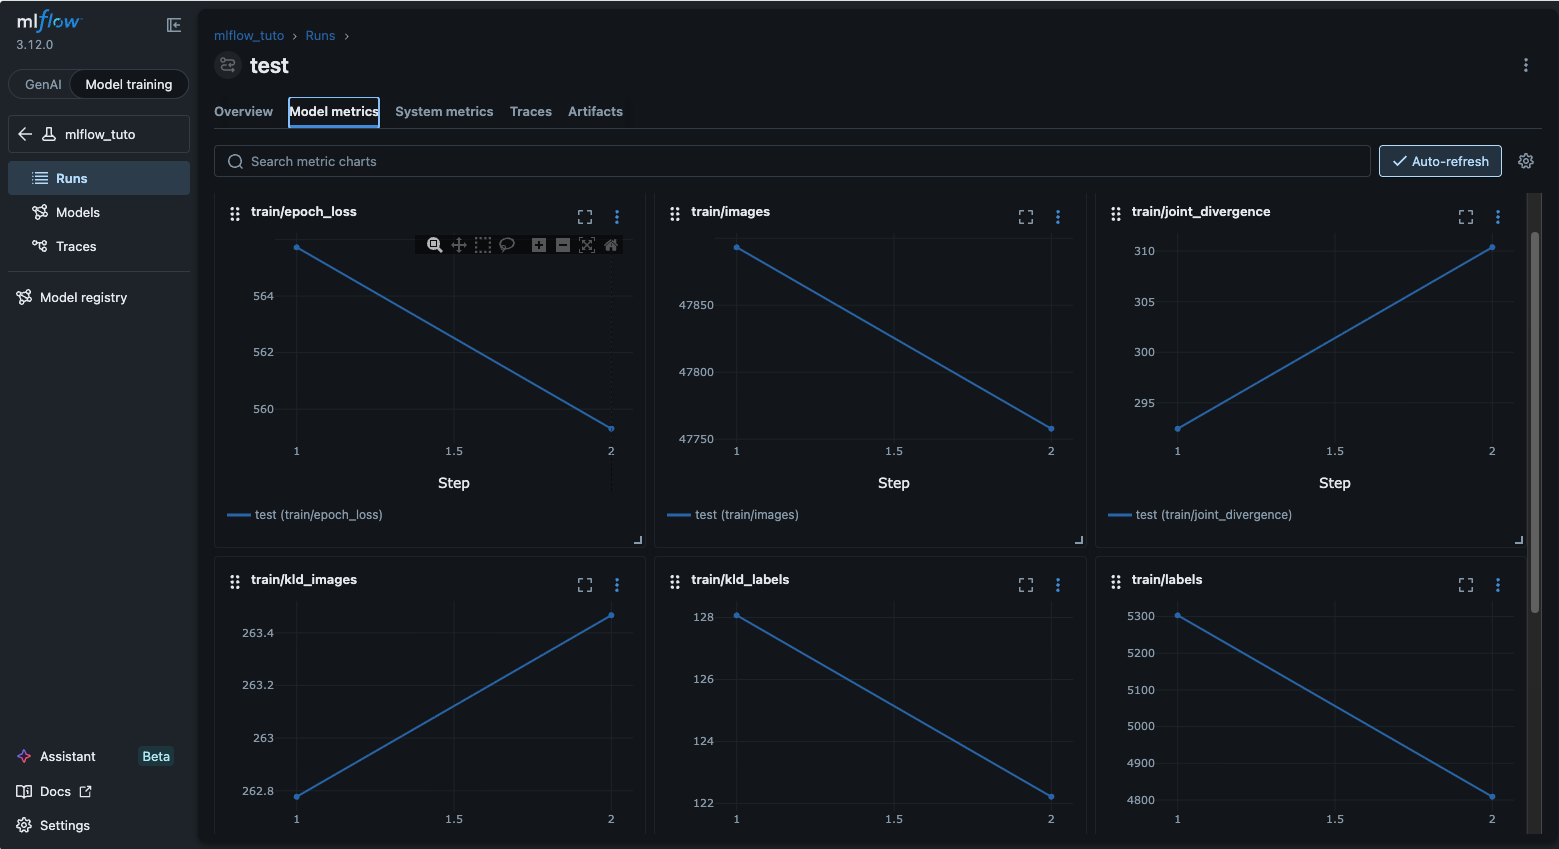

The images are saved as artifacts for each run: 
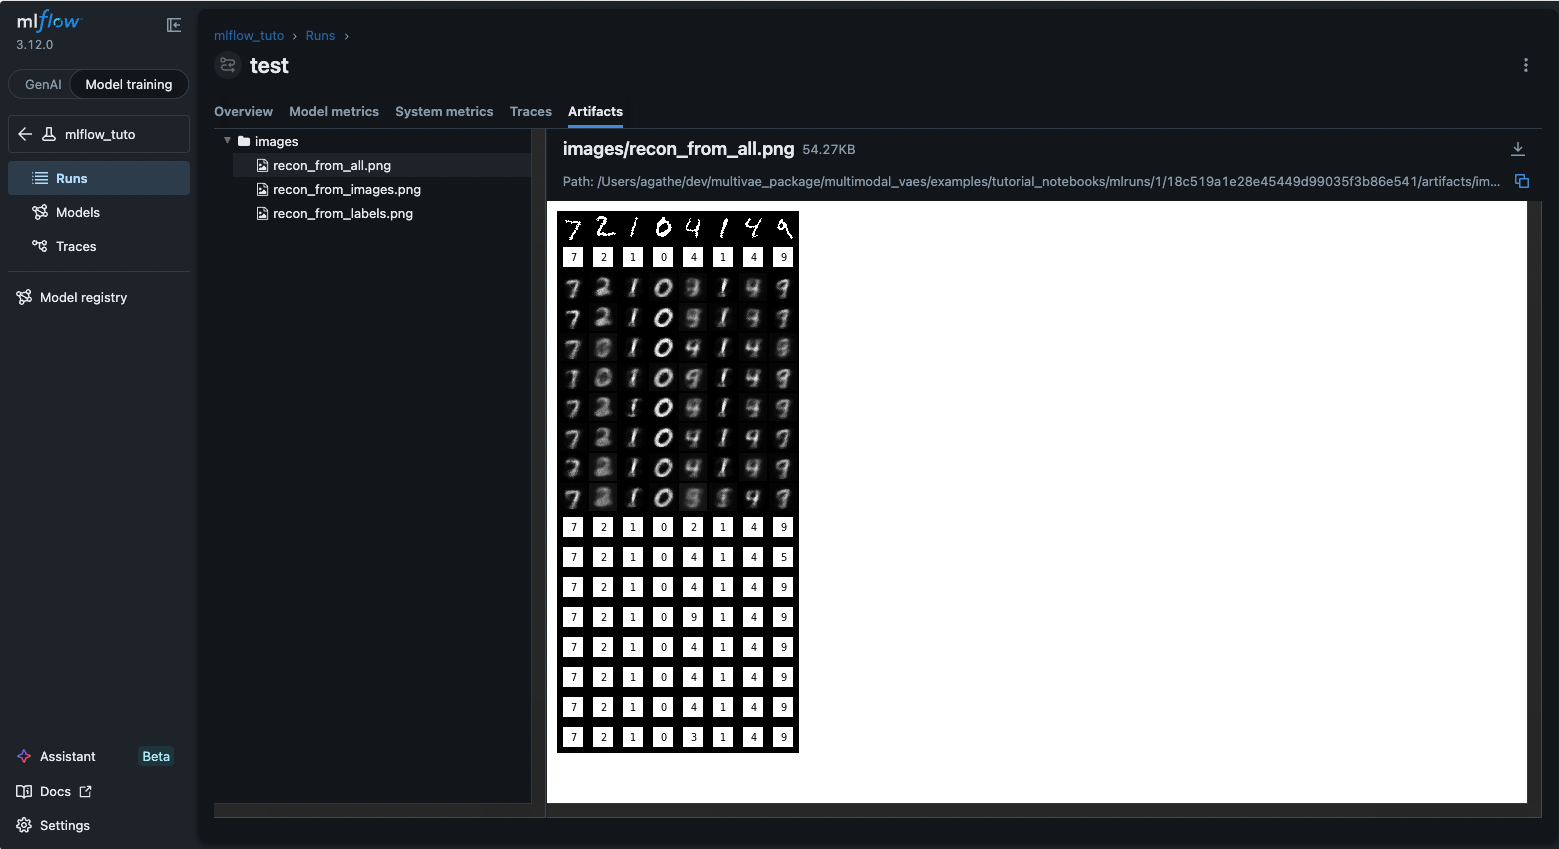